# P96 — Severe Crash Prediction: Model Training
**Dataset:** `master_training_table_v8.csv`  
**Task:** Binary classification — predict whether a crash is severe (1) or not (0)  
**Models:** Random Forest · XGBoost · LightGBM  

> Run cells top to bottom. Make sure `master_training_table_v8.csv` is at `../output/` relative to this notebook.

## Step 0 — Imports & setup

In [15]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay
)
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
%matplotlib inline
print("All libraries imported successfully.")

All libraries imported successfully.


## Step 1 — Paths & config

In [16]:
# ── Adjust DATA_PATH if your CSV is in a different location ──
DATA_PATH = '../output/master_training_table_v8.csv'
MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)
print(f"Data  : {DATA_PATH}")
print(f"Models: {MODEL_DIR}")

Data  : ../output/master_training_table_v8.csv
Models: ../models


## Step 2 — Load data
Read the CSV and inspect the target distribution.

In [17]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
vc = df['severe_crash'].value_counts()
for k, v in vc.items():
    print(f"  severe_crash={k}: {v:,}  ({v/len(df)*100:.1f}%)")
df.head()

Shape: (94398, 24)

Target distribution:
  severe_crash=0: 59,816  (63.4%)
  severe_crash=1: 34,582  (36.6%)


,severe_crash,sample_weight,is_weekend,is_peak_hour,hour_sin,hour_cos,day_sin,day_cos,speed_risk,darkness_score,...,wet_road,LGA_NAME,DEG_URBAN_NAME,NO_OF_VEHICLES,aadt_volume,crash_rate,nearest_school_dist_m,is_public_holiday,is_school_holiday,is_daylight_saving
0,0,1.0,1,0,0.965926,0.258819,-2.449294e-16,1.000000,6,1.0,...,0,WODONGA,RURAL_VICTORIA,1,2847,0.412423,4644.9,0,0,0
1,1,1.5,0,0,-0.707107,-0.707107,-9.749279e-01,-0.222521,1,0.0,...,0,ARARAT,TOWNS,1,0,0.000000,2412.2,0,0,0
2,1,1.5,0,0,0.500000,-0.866025,4.338837e-01,-0.900969,0,0.0,...,0,STONNINGTON,MELB_URBAN,2,2257,5.549163,718.8,0,0,0
3,0,1.0,0,0,-0.965926,0.258819,4.338837e-01,-0.900969,0,1.0,...,0,CENTRAL GOLDFIELDS,RURAL_VICTORIA,1,0,0.000000,2003.8,0,0,0
4,1,1.5,0,0,-0.500000,0.866025,-9.749279e-01,-0.222521,3,0.6,...,0,HUME,MELB_URBAN,2,11222,3.348190,917.7,0,0,0


## Step 3 — Encode categorical columns
ML models need numbers. Convert the 5 text columns to integers using `LabelEncoder`.  
The encoders are saved to disk so the FastAPI `/score` endpoint can decode predictions later.

In [18]:
CAT_COLS = ['ROAD_GEOMETRY_DESC', 'NODE_TYPE', 'road_class', 'LGA_NAME', 'DEG_URBAN_NAME']
label_encoders_v2 = {}

for col in CAT_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders_v2[col] = le
    print(f"  {col}: {len(le.classes_)} classes → integers 0–{len(le.classes_)-1}")

  ROAD_GEOMETRY_DESC: 9 classes → integers 0–8
  NODE_TYPE: 3 classes → integers 0–2
  road_class: 7 classes → integers 0–6
  LGA_NAME: 88 classes → integers 0–87
  DEG_URBAN_NAME: 8 classes → integers 0–7


## Step 4 — Split features and target
- **X** = 22 input features  
- **y** = `severe_crash` (what we predict)  
- **w** = `sample_weight` (1.5 for severe, 1.0 for non-severe — already in the data)

In [19]:
DROP_COLS = ['severe_crash', 'sample_weight']
FEATURE_COLS_v2 = [c for c in df.columns if c not in DROP_COLS]

X = df[FEATURE_COLS_v2]
y = df['severe_crash']
w = df['sample_weight']

print(f"Features ({len(FEATURE_COLS_v2)}):")
for i, c in enumerate(FEATURE_COLS_v2):
    print(f"  {i+1:2d}. {c}")

Features (22):
   1. is_weekend
   2. is_peak_hour
   3. hour_sin
   4. hour_cos
   5. day_sin
   6. day_cos
   7. speed_risk
   8. darkness_score
   9. ROAD_GEOMETRY_DESC
  10. DISTANCE_LOCATION
  11. NODE_TYPE
  12. road_class
  13. wet_road
  14. LGA_NAME
  15. DEG_URBAN_NAME
  16. NO_OF_VEHICLES
  17. aadt_volume
  18. crash_rate
  19. nearest_school_dist_m
  20. is_public_holiday
  21. is_school_holiday
  22. is_daylight_saving


## Step 5 — Train / test split (80 / 20, stratified)
`stratify=y` ensures both halves have the same 63/37 class ratio.

In [20]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train: {len(X_train):,} rows  |  severe=1: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Test : {len(X_test):,} rows  |  severe=1: {y_test.sum():,} ({y_test.mean()*100:.1f}%)")

Train: 75,518 rows  |  severe=1: 27,665 (36.6%)
Test : 18,880 rows  |  severe=1: 6,917 (36.6%)


## Step 6 — Evaluation helper
Reusable function that prints ROC-AUC, PR-AUC, classification report, and plots the confusion matrix.

In [21]:
results = {}

def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    roc    = roc_auc_score(y_te, y_prob)
    pr_auc = average_precision_score(y_te, y_prob)
    cm     = confusion_matrix(y_te, y_pred)

    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(f"  ROC-AUC : {roc:.4f}")
    print(f"  PR-AUC  : {pr_auc:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=['Not severe', 'Severe'], digits=4))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not severe', 'Severe']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{name.lower().replace(" ", "_")}_cm_v2.png'), dpi=120)
    plt.show()

    results[name] = {'roc_auc': roc, 'pr_auc': pr_auc}
    return roc, pr_auc

print("evaluate() function ready.")

evaluate() function ready.


## Step 7 — Model A: Random Forest (baseline)
200 independent trees trained in parallel.  
`class_weight='balanced'` automatically upweights severe crashes during training.

Fitting Random Forest (200 trees)...
Done.


──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
  ROC-AUC : 0.6410
  PR-AUC  : 0.5004

              precision    recall  f1-score   support

  Not severe     0.7707    0.2686    0.3983     11963
      Severe     0.4052    0.8618    0.5512      6917

    accuracy                         0.4859     18880
   macro avg     0.5879    0.5652    0.4748     18880
weighted avg     0.6368    0.4859    0.4544     18880



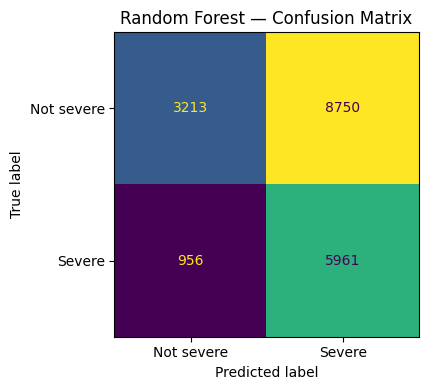

(0.6409815825193073, 0.5003523301733043)

In [22]:
rf_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Fitting Random Forest (200 trees)...")
rf_v2.fit(X_train, y_train, sample_weight=w_train)
print("Done.\n")

evaluate("Random Forest", rf_v2, X_test, y_test)

## Step 8 — Model B: XGBoost (main model)
Gradient boosted trees built sequentially — each tree corrects the previous one's errors.  
`scale_pos_weight` = neg/pos ratio balances the class imbalance.  
`early_stopping_rounds=30` stops training when the test score stops improving.

scale_pos_weight = 1.730  (non-severe / severe ratio)
Fitting XGBoost (up to 500 rounds, early stopping at 30)...
Best iteration: 499


──────────────────────────────────────────────────
  XGBoost
──────────────────────────────────────────────────
  ROC-AUC : 0.6421
  PR-AUC  : 0.4998

              precision    recall  f1-score   support

  Not severe     0.7569    0.3841    0.5096     11963
      Severe     0.4248    0.7866    0.5517      6917

    accuracy                         0.5316     18880
   macro avg     0.5908    0.5854    0.5306     18880
weighted avg     0.6352    0.5316    0.5250     18880



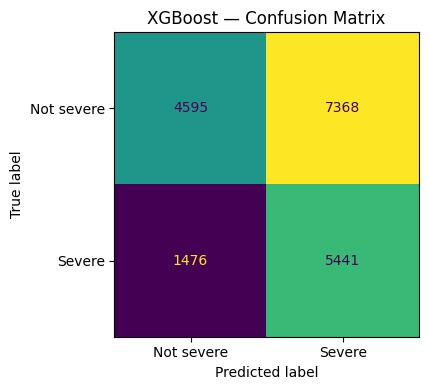

(0.6420728164164696, 0.4997706199884754)

In [23]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {spw:.3f}  (non-severe / severe ratio)")

xgb_model_v2 = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

print("Fitting XGBoost (up to 500 rounds, early stopping at 30)...")
xgb_model_v2.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print(f"Best iteration: {xgb_model_v2.best_iteration}\n")

evaluate("XGBoost", xgb_model_v2, X_test, y_test)

## Step 9 — Model C: LightGBM
Leaf-wise gradient boosting — faster than XGBoost on large datasets.  
`is_unbalance=True` handles the class imbalance automatically.  
`learning_rate=0.01` (reduced from 0.05) prevents early stopping at round 1.

Fitting LightGBM (up to 500 rounds, early stopping at 30)...
Best iteration: 1


──────────────────────────────────────────────────
  LightGBM
──────────────────────────────────────────────────
  ROC-AUC : 0.6204
  PR-AUC  : 0.4659

              precision    recall  f1-score   support

  Not severe     0.6336    1.0000    0.7757     11963
      Severe     0.0000    0.0000    0.0000      6917

    accuracy                         0.6336     18880
   macro avg     0.3168    0.5000    0.3879     18880
weighted avg     0.4015    0.6336    0.4915     18880



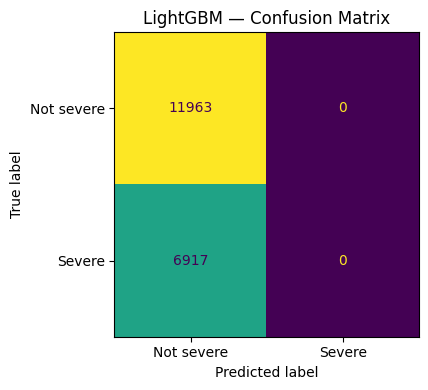

(0.6203795010520546, 0.4659277122431918)

In [24]:
lgbm_model_v2 = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("Fitting LightGBM (up to 500 rounds, early stopping at 30)...")
lgbm_model_v2.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
)
print(f"Best iteration: {lgbm_model_v2.best_iteration_}\n")

evaluate("LightGBM", lgbm_model_v2, X_test, y_test)

## Step 10 — Feature importance (XGBoost)
Which features matter most for predicting crash severity?  
Higher score = the feature reduced prediction error more across all trees.

Top 10 most important features:
  NO_OF_VEHICLES                 0.1392  █████████████████████████████████████████
  darkness_score                 0.0820  ████████████████████████
  speed_risk                     0.0772  ███████████████████████
  DEG_URBAN_NAME                 0.0653  ███████████████████
  day_cos                        0.0549  ████████████████
  LGA_NAME                       0.0459  █████████████
  nearest_school_dist_m          0.0376  ███████████
  ROAD_GEOMETRY_DESC             0.0367  ███████████
  aadt_volume                    0.0364  ██████████
  wet_road                       0.0361  ██████████


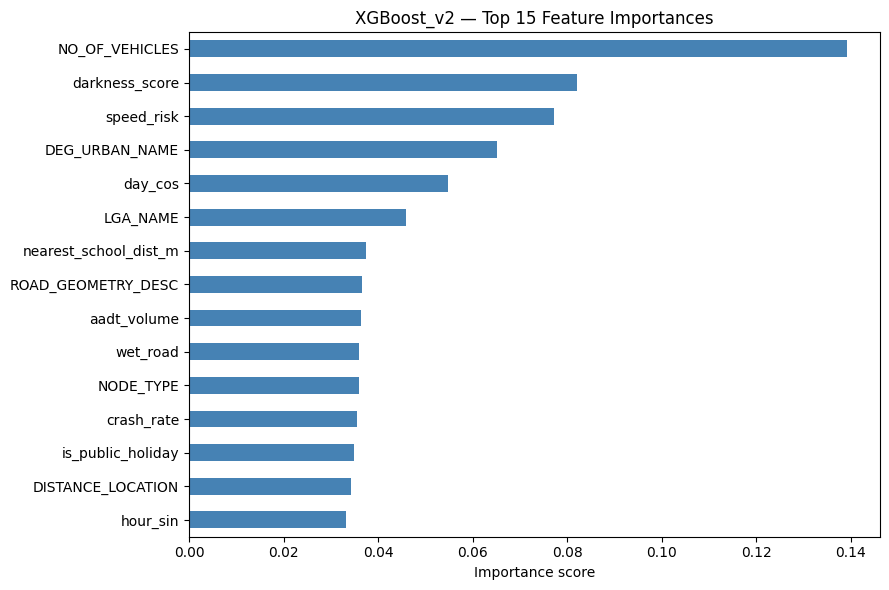

In [25]:
imp = pd.Series(
    xgb_model_v2.feature_importances_,
    index=FEATURE_COLS_v2
).sort_values(ascending=False)

print("Top 10 most important features:")
for feat, score in imp.head(10).items():
    bar = '█' * int(score * 300)
    print(f"  {feat:<30} {score:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(9, 6))
imp.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost_v2 — Top 15 Feature Importances')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'xgboost_v2_feature_importance.png'), dpi=120)
plt.show()

## Step 11 — Model comparison
Side-by-side ROC-AUC and PR-AUC for all three models.

In [26]:
comparison = pd.DataFrame(results).T
comparison.index.name = 'Model'
comparison = comparison.sort_values('roc_auc', ascending=False)

best = comparison.index[0]
print(f"{'Model':<20} {'ROC-AUC':>10} {'PR-AUC':>10}")
print('-' * 44)
for name, row in comparison.iterrows():
    tag = '  ← BEST' if name == best else ''
    print(f"{name:<20} {row['roc_auc']:>10.4f} {row['pr_auc']:>10.4f}{tag}")

comparison

Model                   ROC-AUC     PR-AUC
--------------------------------------------
XGBoost                  0.6421     0.4998  ← BEST
Random Forest            0.6410     0.5004
LightGBM                 0.6204     0.4659


,roc_auc,pr_auc
Model,,
XGBoost,0.642073,0.499771
Random Forest,0.640982,0.500352
LightGBM,0.620380,0.465928


## Step 12 — Save models and encoders
Five files saved to `../models/`:
- `xgboost_model.pkl` — use this in FastAPI `/score`
- `lgbm_model.pkl` / `rf_model.pkl`
- `label_encoders.pkl` — **required at prediction time** to encode categorical inputs
- `feature_columns.pkl` — column order used during training

In [27]:
def save_pkl(obj, filename):
    path = os.path.join(MODEL_DIR, filename)
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    size_kb = os.path.getsize(path) / 1024
    print(f"  Saved: {filename}  ({size_kb:.1f} KB)")

save_pkl(xgb_model_v2,      'xgboost_model_v2.pkl')
save_pkl(lgbm_model_v2,     'lgbm_model_v2.pkl')
save_pkl(rf_v2,             'rf_model_v2.pkl')
save_pkl(label_encoders_v2, 'label_encoders_v2.pkl')
save_pkl(FEATURE_COLS_v2,   'feature_columns_v2.pkl')
print("\nAll files saved.")

  Saved: xgboost_model_v2.pkl  (2203.6 KB)
  Saved: lgbm_model_v2.pkl  (9.2 KB)
  Saved: rf_model_v2.pkl  (28468.8 KB)
  Saved: label_encoders_v2.pkl  (2.0 KB)
  Saved: feature_columns_v2.pkl  (0.3 KB)

All files saved.


## Done — Summary

In [28]:
best_name = comparison.index[0]
best_roc  = comparison.loc[best_name, 'roc_auc']

print("=" * 50)
print("  TRAINING COMPLETE")
print("=" * 50)
print(f"  Training rows : {len(X_train):,}")
print(f"  Test rows     : {len(X_test):,}")
print(f"  Features used : {len(FEATURE_COLS_v2)}")
print(f"  Best model    : {best_name}  (ROC-AUC {best_roc:.4f})")
print()
print("  Saved to ../models/:")
print("    xgboost_model_v2.pkl       ← use in FastAPI /score")
print("    lgbm_model_v2.pkl")
print("    rf_model_v2.pkl")
print("    label_encoders_v2.pkl      ← needed at prediction time")
print("    feature_columns_v2.pkl     ← column order for prediction")

  TRAINING COMPLETE
  Training rows : 75,518
  Test rows     : 18,880
  Features used : 22
  Best model    : XGBoost  (ROC-AUC 0.6421)

  Saved to ../models/:
    xgboost_model_v2.pkl       ← use in FastAPI /score
    lgbm_model_v2.pkl
    rf_model_v2.pkl
    label_encoders_v2.pkl      ← needed at prediction time
    feature_columns_v2.pkl     ← column order for prediction
